<a href="https://colab.research.google.com/github/preethipalanisamy12-source/AlmaBetter-Projects/blob/main/EDA_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -

# **SupplyChain Pulse: Decoding Global Health Commodity Delivery Through EDA**
An Exploratory Data Analysis of SCMS Delivery History to Drive Efficiency, Reduce Costs, and Accelerate Life-Saving Shipments Across 43 Countries.

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Analysed by**     - Preethi P

# **Project Summary -**

The SCMS (Supply Chain Management System) Delivery History dataset captures 10,324 shipment records spanning **2006–2015**, documenting the **global distribution** of HIV/AIDS antiretroviral medications, diagnostic test kits, malaria treatments, and antimalarial drugs across **43 countries** — primarily across Sub-Saharan Africa, with additional shipments to South and Southeast Asia, the Caribbean, and Latin America.
Each record tracks the complete journey of a commodity from procurement request to client delivery, including vendor identity, shipment mode (Air, Air Charter, Truck, Ocean), scheduled vs. actual delivery dates, freight costs, insurance, pack pricing, unit pricing, and manufacturing origin. With **73 distinct vendors** — predominantly Indian pharmaceutical manufacturers — and over **1.63 billion dollars in total shipment value**, this dataset represents a live window into one of the world's most critical humanitarian supply chains.
The core objective of this EDA is to **help FedEx Logistics streamline operations** by surfacing patterns that answer three high-impact business questions: Where are deliveries being delayed, and why? Which shipment modes and vendors deliver the best cost efficiency? And What trends, correlations, and outliers in the data point to systemic supply chain improvements that can lower costs and improve delivery reliability for millions of patients worldwide.

# **GitHub Link -**

https://github.com/preethipalanisamy12-source/AlmaBetter-Projects.git

# **Problem Statement**


**Write Problem Statement Here.**

FedEx Logistics operates a complex global supply chain where maintaining delivery timelines and cost-effectiveness is critical for a competitive advantage. However, the current logistics process indicates significant inefficiencies across three key dimensions.


*   First, **consistent variances between the Scheduled Delivery Date and
Delivered to Client Date** suggest persistent logistical bottleneck.
*   Second, administrative delays are evident in the procurement lead time, specifically the **gap between the PQ First Sent to Client Date and the PO Sent to Vendor Date.**
*   Finally, **unpredictable fluctuations in Freight Cost (USD) and Unit Price** across different Vendors, Shipment Modes (e.g., Air vs. Air Charter), and Manufacturing Sites highlight a lack of cost optimization.

Failure to identify and mitigate these drivers through data-driven analysis risks increased operational expenditures and reduced customer satisfaction, potentially leading to negative business growth.



#### **Define Your Business Objective?**

The primary objective of this exploratory data analysis is to evaluate FedEx Logistics' global operations using a structured Univariate, Bivariate, and Multivariate (UBM) analytical approach.
This project aims to:


*  **Identify high-variance delivery nodes** by correlating Vendors and Manufacturing Sites with actual delivery delays.
*  **Pinpoint administrative bottlenecks** within the procurement cycle by analyzing the time elapsed between quotation and order placement
*  **Evaluate cost-efficiency** by investigating the relationship between Shipment Modes, Line Item Insurance, and molecular Unit Pricing

The ultimate goal is to transform these findings into actionable insights that will allow FedEx Logistics to streamline supply chain operations, reduce unnecessary freight expenses, and ensure a positive business impact for both the company and its global clientele.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)

### Dataset Loading

In [3]:
# Load Dataset
url = "https://raw.githubusercontent.com/preethipalanisamy12-source/AlmaBetter-Projects/refs/heads/main/SCMS_dataset.csv"
scms_data = pd.read_csv(url)

### Dataset First View

In [4]:
# Dataset First Look
print(scms_data.head())
print(scms_data.tail())

   ID Project Code            PQ # PO / SO # ASN/DN #        Country  \
0   1   100-CI-T01  Pre-PQ Process    SCMS-4    ASN-8  Côte d'Ivoire   
1   3   108-VN-T01  Pre-PQ Process   SCMS-13   ASN-85        Vietnam   
2   4   100-CI-T01  Pre-PQ Process   SCMS-20   ASN-14  Côte d'Ivoire   
3  15   108-VN-T01  Pre-PQ Process   SCMS-78   ASN-50        Vietnam   
4  16   108-VN-T01  Pre-PQ Process   SCMS-81   ASN-55        Vietnam   

  Managed By  Fulfill Via Vendor INCO Term Shipment Mode  \
0   PMO - US  Direct Drop              EXW           Air   
1   PMO - US  Direct Drop              EXW           Air   
2   PMO - US  Direct Drop              FCA           Air   
3   PMO - US  Direct Drop              EXW           Air   
4   PMO - US  Direct Drop              EXW           Air   

  PQ First Sent to Client Date PO Sent to Vendor Date Scheduled Delivery Date  \
0               Pre-PQ Process      Date Not Captured                2-Jun-06   
1               Pre-PQ Process      Date Not



*   33 Variables (Max Row: 10,323 | Max ID: 86,823) ➔ **Non-continuous ID range** — contains only the subset of whole data.

*  **Date, Cost & Weight Columns** (**Mixed Qualitative Text**) ➔ "Pre-PQ Process", "Freight Included", "See DN-#" — placeholders require heavy cleaning and type-casting.

### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
print(scms_data.shape)
print(scms_data.index)
print(scms_data.columns)

(10324, 33)
RangeIndex(start=0, stop=10324, step=1)
Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')


### Dataset Information

In [6]:
# Dataset Info
scms_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

*  **Date Columns (Stored as Object)** ➔ Contains placeholders preventing type conversion to datetime64.

*  **Cost & Weight (Stored as Object)** ➔ Contains placeholders preventing type conversion to float64.

*  **3 Null Columns (Text Placeholders)**➔ Standard null-counts underreport the true data gaps.

#### Duplicate Values

In [65]:
print(f"Complete row duplicates : {scms_data.duplicated().sum()}")

print("PO/SO# duplicates:", scms_data['PO / SO #'].duplicated().sum())
print("ASN/DN# duplicates:", scms_data['ASN/DN #'].duplicated().sum())

item_cols = ['PO / SO #', 'ASN/DN #', 'Item Description', 'Line Item Quantity', 'Line Item Value']

item_dupes = scms_data.duplicated(subset= item_cols, keep=False)
print(f"Item Duplicates: {item_dupes.sum()}")

Complete row duplicates : 0
PO/SO# duplicates: 4091
ASN/DN# duplicates: 3294
Item Duplicates: 32


* **Purchase Orders & Shipment Notices**: High volume of duplicate entries. Conversely, there is a low volume of actual item duplicates, which confirms the data is structured as a line-item ledger.

* **Quantity Duplicates** (Same Item): Identified as **Order Splitting **(multiple line items or partial shipments for the same product).

* **Shipment Notice Duplicates**: Source unclear; requires targeted investigation.

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
standard_nulls = scms_data.isnull().sum() #Missing values as NaN - only 3 columns.
print(standard_nulls)

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [10]:
scms_hidden_nulls = scms_data.copy()

# 1. Replacing exact text phrases which are placeholders.
exact_texts = [
    'Pre-PQ Process',
    'Date Not Captured',
    'Weight Captured Separately',
    'Invoiced Separately',
    'Freight Included in Commodity Cost'
]
scms_hidden_nulls = scms_hidden_nulls.replace(exact_texts, np.nan)

# 2. Replacing partial regex patterns.
scms_hidden_nulls = scms_hidden_nulls.replace(r'.*See.*', np.nan, regex=True)

# 3. Calculating total null values
total_nulls = scms_hidden_nulls.isnull().sum().sort_values(ascending=False)
print(total_nulls)

Freight Cost (USD)              4126
Weight (Kilograms)              3952
PQ #                            2681
PQ First Sent to Client Date    2681
Dosage                          1736
Shipment Mode                    360
PO Sent to Vendor Date           328
Line Item Insurance (USD)        287
ID                                 0
Vendor INCO Term                   0
Fulfill Via                        0
Managed By                         0
Scheduled Delivery Date            0
Country                            0
Project Code                       0
PO / SO #                          0
ASN/DN #                           0
Sub Classification                 0
Product Group                      0
Delivery Recorded Date             0
Delivered to Client Date           0
Brand                              0
Vendor                             0
Molecule/Test Type                 0
Item Description                   0
Line Item Quantity                 0
Unit of Measure (Per Pack)         0
D

**Visualising Null Values**

/tmp/ipykernel_962/3374494094.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  scms_hidden_nulls['Scheduled Delivery Date'] = pd.to_datetime(scms_hidden_nulls['Scheduled Delivery Date'], errors='coerce')


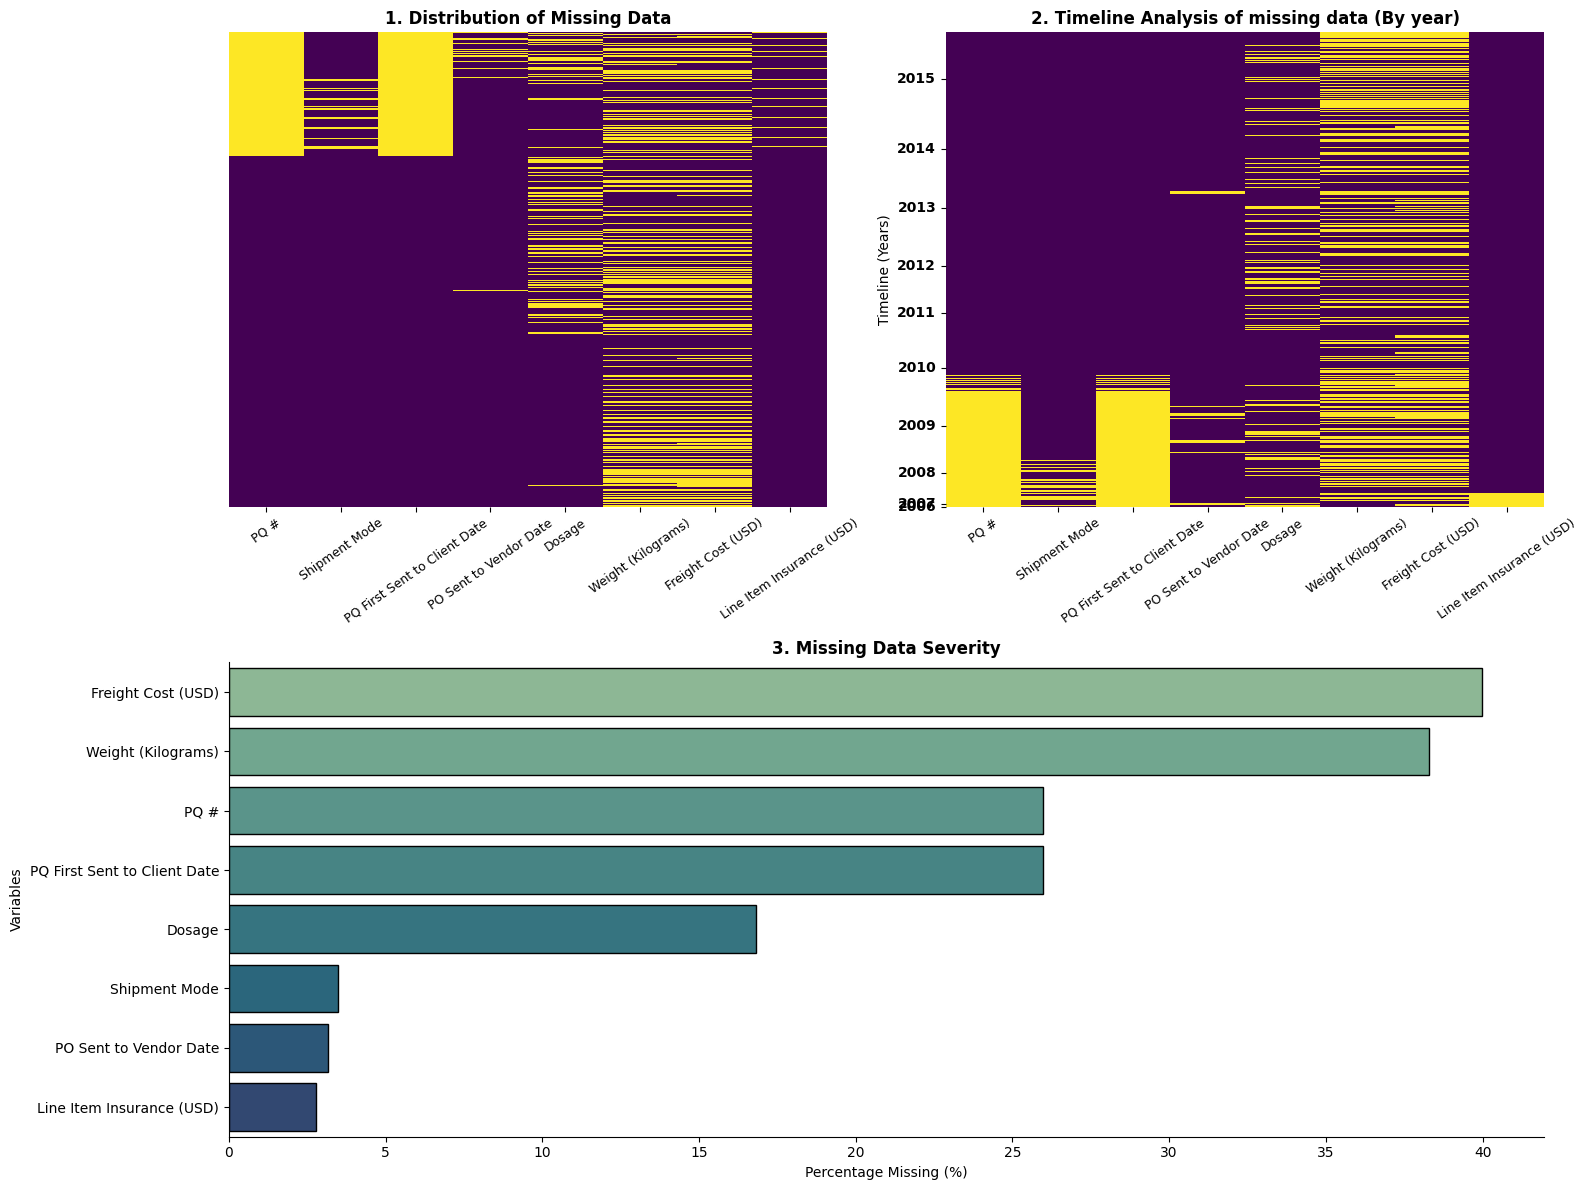

In [11]:
# Creating Layout
fig = plt.figure(figsize=(16, 12))
ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 1, 2)

#extracting only the columns with null values for clear visualisation
all_null_cols = scms_hidden_nulls.columns[scms_hidden_nulls.isnull().any()].tolist()


# CHART 1: UNSORTED HEATMAP
sns.heatmap(scms_hidden_nulls[all_null_cols].isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=ax1)
ax1.set_title("1. Distribution of Missing Data", fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=35, labelsize=9)

# CHART 2: CHRONOLOGICAL HEATMAP
scms_hidden_nulls['Scheduled Delivery Date'] = pd.to_datetime(scms_hidden_nulls['Scheduled Delivery Date'], errors='coerce')

#prepping the data for sorting the data yearwise
df_clean_dates = scms_hidden_nulls.dropna(subset=['Scheduled Delivery Date'])
df_chronological = df_clean_dates.sort_values(by='Scheduled Delivery Date', ascending=True).reset_index(drop=True)
df_chronological['Year'] = df_chronological['Scheduled Delivery Date'].dt.year
year_positions = df_chronological.groupby('Year').idxmin()['Scheduled Delivery Date']

#plotting the map in chronocological order
sns.heatmap(df_chronological[all_null_cols].isnull(), cbar=False, cmap='viridis', ax=ax2)
ax2.set_yticks(year_positions.values)
ax2.set_yticklabels(year_positions.index, rotation=0, fontweight='bold')
ax2.invert_yaxis()  # Keeps oldest years at the top flowing down
ax2.set_title("2. Timeline Analysis of missing data (By year)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Timeline (Years)")
ax2.tick_params(axis='x', rotation=35, labelsize=9)

# CHART 3: SEVERITY BAR CHART (ALL NULL COLUMNS)

#calculating the % of null values
null_pct = (scms_hidden_nulls.isnull().mean() * 100).reset_index()
null_pct.columns = ['Column', 'Percentage']
null_pct = null_pct[null_pct['Percentage'] > 0].sort_values(by='Percentage', ascending=False)

#horizontal severity comparison bar chart
sns.barplot(x='Percentage', y='Column', data=null_pct, palette='crest', hue='Column', edgecolor='black', ax=ax3)
ax3.set_title("3. Missing Data Severity", fontsize=12, fontweight='bold')
ax3.set_xlabel("Percentage Missing (%)")
ax3.set_ylabel("Variables")
sns.despine(ax=ax3)

plt.tight_layout()
plt.show()

**Insights from visualisation**

**Chart 1 (Missing Value Distribution)**➔ Freight cost and weight nulls are scattered uniformly — other missing data is highly concentrated.

**Chart 2 (Chronological Correlation)** ➔ Concentrated nulls align with pre-2010 timelines — suggests poor data logging standards in legacy records.

**Chart 3 (Missingness Severity)** ➔ Null density peaks in columns containing text placeholders — demands extensive, targeted data cleaning.


### What did you know about your dataset?

*  **End-to-End Scope**: The SCMS dataset provides comprehensive visibility into the global health product supply chain from 2006 to 2015 across 33 variables
*  **Sampling Context**: Non-continuous Order IDs (reaching 86,823) confirm that we are analysing an operational subset rather than a complete transactional archive
*  **Technical Roadblocks**: Qualitative strings such as "Pre-PQ Process" and "Date Not Captured" function as operational nulls, preventing immediate numerical typecasting and timeline analysis
*  **Data Maturity Trend**: Integrity gaps in quotations and insurance are concentrated in records pre-2010, indicating a legacy of inconsistent logging that improved as digital tracking matured
*  **Line-Item Architecture**: Logical duplicates in PO/SO and ASN/DN numbers suggest that orders and shipments are frequently consolidated, containing multiple distinct product line items per transaction
*  **Logistics Metadata**: Detailed shipment modes (Air, Truck, Ocean, Air Charter) and weight references (e.g., "See ASN-...") provide the categorical depth required for a multi-layered analysis of delivery efficiency

## ***2. Understanding Your Variables***

In [12]:
# Dataset Columns
scms_data.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

In [33]:
# Dataset Describe
scms_data.describe()


,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


In [34]:
scms_data.describe(include = 'object')

,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD)
count,10324,10324,10324,10324,10324,10324,10324,10324,9964,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,8588,10324,10324,10324,10324,10324
unique,142,1237,6233,7030,43,4,2,8,4,765,897,2006,2093,2042,5,6,73,184,86,48,54,17,88,2,4688,6733
top,116-ZA-T30,Pre-PQ Process,SCMS-199289,ASN-19166,South Africa,PMO - US,From RDC,N/A - From RDC,Air,Pre-PQ Process,N/A - From RDC,29-Aug-14,29-Aug-14,29-Aug-14,ARV,Adult,SCMS from RDC,"Efavirenz 600mg, tablets, 30 Tabs",Efavirenz,Generic,300mg,Tablet,"Aurobindo Unit III, India",Yes,Weight Captured Separately,Freight Included in Commodity Cost
freq,768,2681,67,54,1406,10265,5404,5404,6113,2476,5404,97,74,67,8550,6595,5404,755,1125,7285,990,3532,3172,7030,1507,1442


### Variables Description

* **Wide Volume Range**: Order quantities vary from 1 to 619,999 units, reflecting both small emergency shipments and large-scale replenishments.
* **Pack Size Variability**: Packs range from 1 to 1,000 units, influencing shipment weight and freight costs.
* **Incomplete Insurance Data**: Insurance values reach $7,700, but many records are marked as "Invoiced Separately", limiting total cost visibility.
* **Complex Supply Network**: The dataset spans 142 initiatives, 73 vendors, 88 manufacturing sites, and 43 countries.
* **Potential Delivery Drivers**: High vendor and manufacturing-site diversity may contribute to lead-time variability.
* **Priority Assessment Needed**: Further analysis is required to determine whether First Line Designated products receive faster processing.

### Check Unique Values for each variable.

In [36]:
# Check Unique Values for each variable.
scms_data.nunique().sort_values(ascending = False)

,0
ID,10324
Line Item Value,8741
ASN/DN #,7030
Freight Cost (USD),6733
Line Item Insurance (USD),6722
PO / SO #,6233
Line Item Quantity,5065
Weight (Kilograms),4688
Delivered to Client Date,2093
Delivery Recorded Date,2042


## 3. ***Data Wrangling***

### Data Wrangling Code

Handling Duplicates

### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [16]:
# Chart - 1 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

In [17]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [18]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [19]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [20]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [21]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [22]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [23]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [24]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [25]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [26]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [27]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [28]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [29]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [30]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***